# ResNet50 with Transfer Learning

### Import libraries

In [1]:
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [9]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.layers import Input, Lambda, Dense, Flatten, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing import image

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [8]:
print (tf.__version__)

2.19.0


In [9]:
print(keras.__version__)

3.10.0


### Data Preprocessing

In [3]:
BATCH_SIZE = 32
IMAGE_SIZE = [224,224]
SEED = 123
VALIDATION_SPLIT = 0.1
TEST_SPLIT = 0.1

In [4]:
# Load the entire dataset
full_ds = tf.keras.preprocessing.image_dataset_from_directory(
    'dataset-original',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED #Shuffle
)

Found 2527 files belonging to 6 classes.


In [5]:
dataset_name = full_ds
class_names = dataset_name.class_names
print(class_names)

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [6]:
# Calculate splits based on NUMBER OF BATCHES (not images)
total_batches = len(full_ds)
num_test_batches = int(total_batches * TEST_SPLIT)
num_val_batches = int(total_batches * VALIDATION_SPLIT)
num_train_batches = total_batches - num_test_batches - num_val_batches

print(f'Total Batches: {total_batches}')
print(f'Batches allocated for Training: {num_train_batches}')
print(f'Batches allocated for Validation: {num_val_batches}')
print(f'Batches allocated for Testing: {num_test_batches}')

# Approximate total images (last batch might be smaller)
approx_total_images = total_batches * BATCH_SIZE
print(f'Approximate Total Images: {approx_total_images}')

# Create datasets using batch-based slicing
train_ds = full_ds.take(num_train_batches)
val_ds = full_ds.skip(num_train_batches).take(num_val_batches)
test_ds = full_ds.skip(num_train_batches + num_val_batches)

def count_images_in_dataset(dataset):
    count = 0
    for batch in dataset:
        count += batch[0].shape[0]  # batch[0] is images, shape[0] is batch size
    return count

print(f'Actual images in train_ds: {count_images_in_dataset(train_ds)}')
print(f'Actual images in val_ds: {count_images_in_dataset(val_ds)}')
print(f'Actual images in test_ds: {count_images_in_dataset(test_ds)}')

Total Batches: 79
Batches allocated for Training: 65
Batches allocated for Validation: 7
Batches allocated for Testing: 7
Approximate Total Images: 2528
Actual images in train_ds: 2080
Actual images in val_ds: 224
Actual images in test_ds: 223


In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

In [11]:
# Use preprocess_input
train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))
test_ds = test_ds.map(lambda x, y: (preprocess_input(x), y))

In [12]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

### Training

In [14]:
pretrained_model = tf.keras.applications.ResNet50(
    include_top=False,
    input_shape=(224,224,3),
    pooling=None, # removed avg to be able to use GlobalAveragePooling2D
    weights='imagenet'
)

# Unfreeze the last few layers for fine-tuning
for layer in pretrained_model.layers[:-20]:  # Freeze first layers
    layer.trainable = False
for layer in pretrained_model.layers[-20:]:  # Unfreeze last 20 layers
    layer.trainable = True
      
resnet50_model = tf.keras.Sequential([
    pretrained_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(6, activation='softmax')
])

In [15]:
resnet50_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)                │ (None, 7, 7, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 2048)                │           8,192 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       1,049,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 6)                   │           1,542 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,779,910 (94.53 MB)

 Trainable params: 10,118,406 (38.60 MB)

 Non-trainable params: 14,661,504 (55.93 MB)

In [16]:
resnet50_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
# Callbacks for better training
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7
    )
]

In [18]:
history = resnet50_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step - accuracy: 0.3566 - loss: 1.7674 - val_accuracy: 0.7232 - val_loss: 0.7688 - learning_rate: 1.0000e-04
Epoch 2/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.7651 - loss: 0.6838 - val_accuracy: 0.8170 - val_loss: 0.5251 - learning_rate: 1.0000e-04
Epoch 3/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.8701 - loss: 0.3999 - val_accuracy: 0.8661 - val_loss: 0.4493 - learning_rate: 1.0000e-04
Epoch 4/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.9350 - loss: 0.2148 - val_accuracy: 0.8616 - val_loss: 0.4245 - learning_rate: 1.0000e-04
Epoch 5/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.9718 - loss: 0.1162 - val_accuracy: 0.8616 - val_loss: 0.4206 - learning_rate: 1.0000e-04
Epoch 6/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 63s 965ms/step - accuracy: 0.9871 - loss: 0.0621 - val_accuracy: 0.8705 - val_loss: 0.3840 - learning_rate: 1.0000e-04
Epoch 7/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 62s 951ms/step - accuracy: 0.9901 

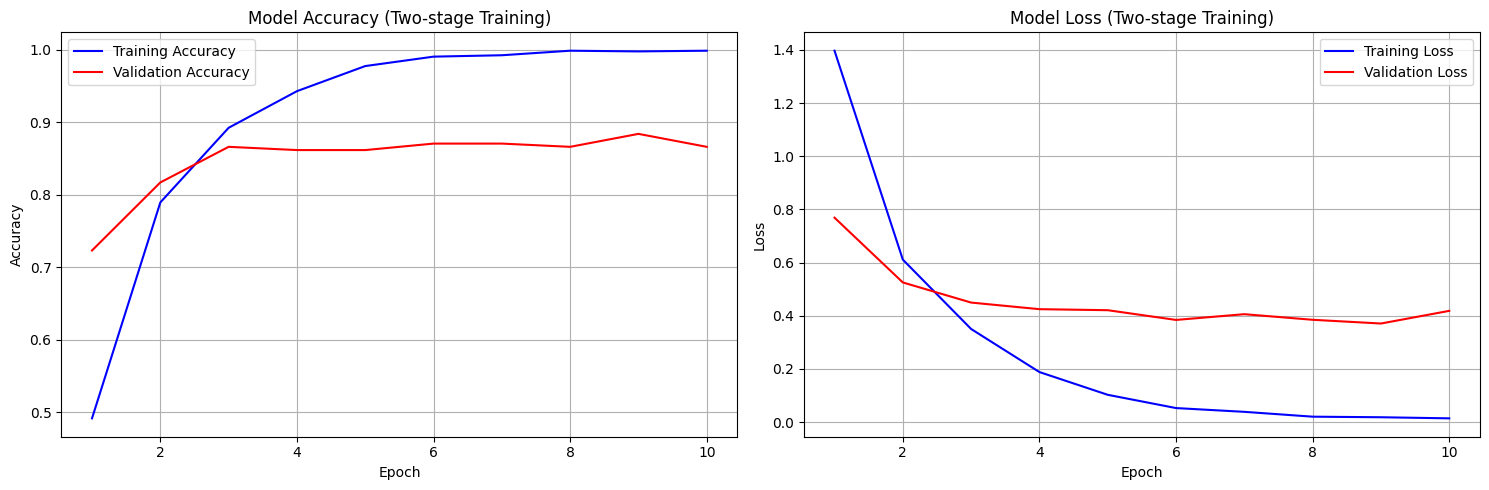

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy plot
total_epochs = 10

ax1.plot(range(1, total_epochs + 1), history.history['accuracy'], 'b-', label='Training Accuracy')
ax1.plot(range(1, total_epochs + 1), history.history['val_accuracy'], 'r-', label='Validation Accuracy')
ax1.set_title('Model Accuracy (Two-stage Training)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss plot
ax2.plot(range(1, total_epochs + 1), history.history['loss'], 'b-', label='Training Loss')
ax2.plot(range(1, total_epochs + 1), history.history['val_loss'], 'r-', label='Validation Loss')
ax2.set_title('Model Loss (Two-stage Training)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [20]:
# Final evaluation
print("\n" + "="*50)
print("FINAL MODEL EVALUATION")
print("="*50)

final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
best_val_acc = max(history.history['val_accuracy'])

print(f"Final Training Accuracy: {final_train_acc:.4f} ({final_train_acc*100:.2f}%)")
print(f"Final Validation Accuracy: {final_val_acc:.4f} ({final_val_acc*100:.2f}%)")
print(f"Best Validation Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")


FINAL MODEL EVALUATION
Final Training Accuracy: 0.9986 (99.86%)
Final Validation Accuracy: 0.8661 (86.61%)
Best Validation Accuracy: 0.8839 (88.39%)


### Evaluation

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [22]:
# Get predictions from the test dataset
y_true = []  # True labels
y_pred = []  # Predicted labels

# Iterate through the test dataset to collect true labels and predictions
for images, labels in test_ds:
    predictions = resnet50_model.predict(images)
    y_true.extend(labels.numpy())  # Append true labels
    y_pred.extend(np.argmax(predictions, axis=1))  # Append predicted labels

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 751ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 805ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 798ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 721ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 759ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [23]:
# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
error_rate = 1 - accuracy

print("\n" + "="*50)
print("MODEL EVALUATION METRICS")
print("="*50)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1-Score (weighted): {f1:.4f}")
print(f"Error Rate: {error_rate:.4f} ({error_rate*100:.2f}%)")


MODEL EVALUATION METRICS
Accuracy: 0.8879 (88.79%)
Precision (weighted): 0.8910
Recall (weighted): 0.8879
F1-Score (weighted): 0.8869
Error Rate: 0.1121 (11.21%)


In [24]:
# Generate classification report
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

              precision    recall  f1-score   support

   cardboard       0.89      0.94      0.91        34
       glass       0.85      0.93      0.89        55
       metal       0.86      0.94      0.90        33
       paper       0.94      0.89      0.92        57
     plastic       0.93      0.74      0.82        34
       trash       0.80      0.80      0.80        10

    accuracy                           0.89       223
   macro avg       0.88      0.87      0.87       223
weighted avg       0.89      0.89      0.89       223




CONFUSION MATRIX
Raw confusion matrix:
[[32  0  0  2  0  0]
 [ 0 51  2  0  1  1]
 [ 0  2 31  0  0  0]
 [ 4  0  0 51  1  1]
 [ 0  6  3  0 25  0]
 [ 0  1  0  1  0  8]]


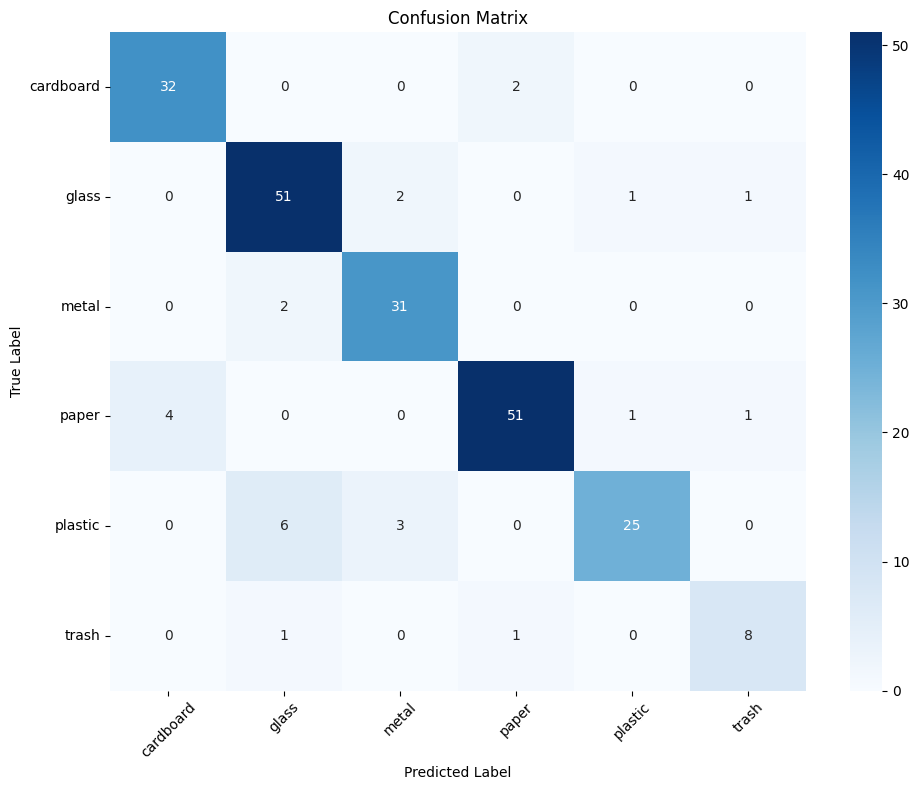

In [25]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print("\n" + "="*50)
print("CONFUSION MATRIX")
print("="*50)
print("Raw confusion matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Save model

In [26]:
# Save model
resnet50_model.save('resnet50_model.h5', save_format='h5')
print(f"\n Model saved as 'resnet50_model.h5'")


 Model saved as 'resnet50_model.h5'
